In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [2]:
df = pd.read_csv(r"C:\ds and AI\ALL DATASETS\semiconductor_wafer_defect_dataset.csv")

print(df.shape)

df.head()

(5000, 9)


,wafer_id,temperature_c,pressure_torr,gas_flow_sccm,etch_rate_nm_min,voltage_v,current_ma,process_step,defect_label
0,1,457.450712,747.287210,113.215053,93.852614,5.139314,20.341747,Deposition,0
1,2,447.926035,746.397577,116.945005,94.738753,5.113329,20.024511,Lithography,0
2,3,459.715328,706.130705,114.026189,95.514359,4.625392,19.137690,Deposition,0
3,4,472.845448,750.097294,121.104180,102.574892,5.231834,19.994947,Deposition,0
4,5,446.487699,781.984872,131.971785,89.022262,4.403967,20.981683,Deposition,0


In [3]:
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDefect Distribution")
print(df["defect_label"].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   wafer_id          5000 non-null   int64  
 1   temperature_c     5000 non-null   float64
 2   pressure_torr     5000 non-null   float64
 3   gas_flow_sccm     5000 non-null   float64
 4   etch_rate_nm_min  5000 non-null   float64
 5   voltage_v         5000 non-null   float64
 6   current_ma        5000 non-null   float64
 7   process_step      5000 non-null   str    
 8   defect_label      5000 non-null   int64  
dtypes: float64(6), int64(2), str(1)
memory usage: 390.5 KB
None

Missing Values
wafer_id            0
temperature_c       0
pressure_torr       0
gas_flow_sccm       0
etch_rate_nm_min    0
voltage_v           0
current_ma          0
process_step        0
defect_label        0
dtype: int64

Defect Distribution
defect_label
0    4993
1       7
Name: count, dtype: int64


In [4]:
defect_percent = (
    df["defect_label"].sum()
    /
    len(df)
)*100

print(f"Defect Rate: {defect_percent:.4f}%")

Defect Rate: 0.1400%


In [5]:
le = LabelEncoder()

df["process_step_encoded"] = le.fit_transform(
    df["process_step"]
)

df.head()

,wafer_id,temperature_c,pressure_torr,gas_flow_sccm,etch_rate_nm_min,voltage_v,current_ma,process_step,defect_label,process_step_encoded
0,1,457.450712,747.287210,113.215053,93.852614,5.139314,20.341747,Deposition,0,1
1,2,447.926035,746.397577,116.945005,94.738753,5.113329,20.024511,Lithography,0,3
2,3,459.715328,706.130705,114.026189,95.514359,4.625392,19.137690,Deposition,0,1
3,4,472.845448,750.097294,121.104180,102.574892,5.231834,19.994947,Deposition,0,1
4,5,446.487699,781.984872,131.971785,89.022262,4.403967,20.981683,Deposition,0,1


In [6]:
features = [
    "temperature_c",
    "pressure_torr",
    "gas_flow_sccm",
    "etch_rate_nm_min",
    "voltage_v",
    "current_ma",
    "process_step_encoded"
]

X = df[features]

y = df["defect_label"]

In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(5000, 7)


In [8]:
z_scores = np.abs(
    (X - X.mean()) / X.std()
)

z_anomaly = (
    z_scores > 3
).any(axis=1)

df["zscore_anomaly"] = z_anomaly.astype(int)

print(df["zscore_anomaly"].value_counts())

zscore_anomaly
0    4916
1      84
Name: count, dtype: int64


In [9]:
iso = IsolationForest(
    n_estimators=500,
    contamination=0.002,
    random_state=42
)

iso.fit(X_scaled)

iso_pred = iso.predict(X_scaled)

iso_pred = np.where(
    iso_pred == -1,
    1,
    0
)

df["isolation_forest"] = iso_pred

In [10]:
df["iforest_score"] = (
    -iso.decision_function(X_scaled)
)

df[
    ["iforest_score"]
].describe()

,iforest_score
count,5000.000000
mean,-0.119044
std,0.037078
min,-0.194772
25%,-0.147072
50%,-0.123407
75%,-0.095247
max,0.031452


In [11]:
svm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.002
)

svm.fit(X_scaled)

svm_pred = svm.predict(X_scaled)

svm_pred = np.where(
    svm_pred == -1,
    1,
    0
)

df["oneclass_svm"] = svm_pred



In [27]:
df["svm_score"] = -svm.decision_function(
    X_scaled
)

In [29]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.002,
    novelty=True
)

lof.fit(X_scaled)

lof_pred = lof.predict(X_scaled)

lof_pred = np.where(
    lof_pred == -1,
    1,
    0
)

df["lof_anomaly"] = lof_pred

df["lof_score"] = -lof.decision_function(
    X_scaled
)

In [12]:
df["ensemble_anomaly"] = (
    df["zscore_anomaly"]
    +
    df["isolation_forest"]
    +
    df["oneclass_svm"]
)

df["final_prediction"] = np.where(
    df["ensemble_anomaly"] >= 2,
    1,
    0
)

df["final_prediction"].value_counts()

final_prediction
0    4972
1      28
Name: count, dtype: int64

In [13]:
print(
    classification_report(
        y,
        df["final_prediction"]
    )
)

              precision    recall  f1-score   support

           0       1.00      0.99      1.00      4993
           1       0.04      0.14      0.06         7

    accuracy                           0.99      5000
   macro avg       0.52      0.57      0.53      5000
weighted avg       1.00      0.99      1.00      5000



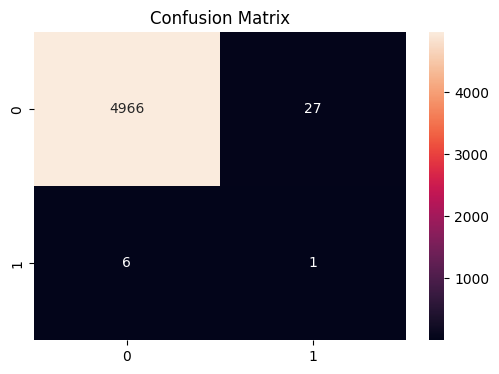

In [14]:
cm = confusion_matrix(
    y,
    df["final_prediction"]
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title(
    "Confusion Matrix"
)

plt.show()

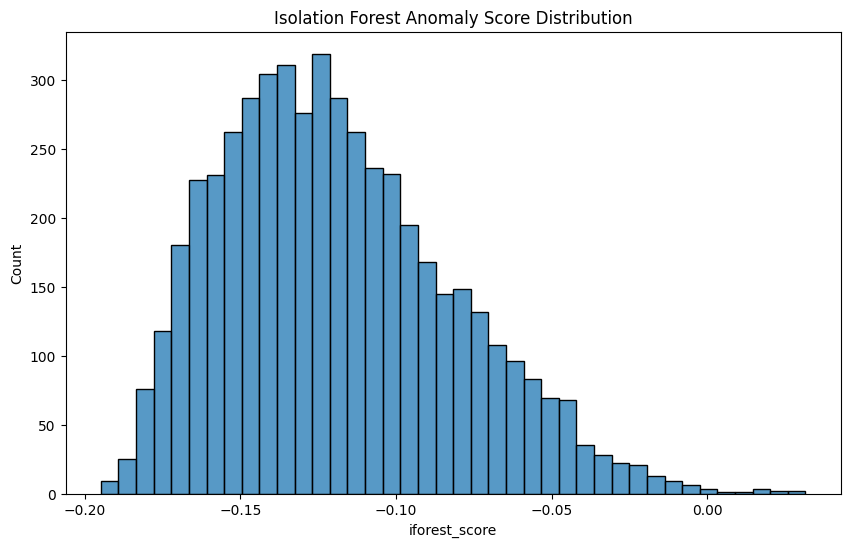

In [15]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["iforest_score"],
    bins=40
)

plt.title(
    "Isolation Forest Anomaly Score Distribution"
)

plt.show()

In [16]:
top_anomalies = df.sort_values(
    "iforest_score",
    ascending=False
)

top_anomalies[
[
    "wafer_id",
    "iforest_score",
    "defect_label"
]
].head(20)

,wafer_id,iforest_score,defect_label
3562,3563,0.031452,0
3405,3406,0.029956,0
4033,4034,0.023321,0
3602,3603,0.022979,0
2874,2875,0.019357,0
507,508,0.019195,0
4891,4892,0.018539,0
980,981,0.014082,0
1957,1958,0.004490,0
447,448,0.002513,0


In [17]:
df["power"] = (
    df["voltage_v"]
    *
    df["current_ma"]
)

In [18]:
from sklearn.decomposition import PCA

In [20]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df["PC1"] = X_pca[:,0]
df["PC2"] = X_pca[:,1]

In [21]:
feature_importance = np.abs(
X.corrwith(
df["final_prediction"]
)
)

In [25]:
import pandas as pd
import numpy as np
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

# -------------------
# LOAD DATA
# -------------------

df = pd.read_csv(
    r"C:\ds and AI\ALL DATASETS\semiconductor_wafer_defect_dataset.csv"
)

# -------------------
# ENCODING
# -------------------

le = LabelEncoder()

df["process_step_encoded"] = le.fit_transform(
    df["process_step"]
)

# -------------------
# FEATURES
# -------------------

features = [
    "temperature_c",
    "pressure_torr",
    "gas_flow_sccm",
    "etch_rate_nm_min",
    "voltage_v",
    "current_ma",
    "process_step_encoded"
]

X = df[features]

# -------------------
# SCALING
# -------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# -------------------
# ISOLATION FOREST
# -------------------

iso = IsolationForest(
    n_estimators=500,
    contamination=0.002,
    random_state=42
)

iso.fit(X_scaled)

# -------------------
# ONE CLASS SVM
# -------------------

svm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.002
)

svm.fit(X_scaled)

# -------------------
# SAVE
# -------------------

import os

os.makedirs("models", exist_ok=True)

joblib.dump(
    scaler,
    "models/scaler.pkl"
)

joblib.dump(
    iso,
    "models/isolation_forest.pkl"
)

joblib.dump(
    svm,
    "models/oneclass_svm.pkl"
)

print("Models Saved Successfully")

Models Saved Successfully


In [26]:
import pandas as pd

df = pd.read_csv( r"C:\ds and AI\ALL DATASETS\semiconductor_wafer_defect_dataset.csv")

print(df.columns.tolist())
print(df.head())

['wafer_id', 'temperature_c', 'pressure_torr', 'gas_flow_sccm', 'etch_rate_nm_min', 'voltage_v', 'current_ma', 'process_step', 'defect_label']
   wafer_id  temperature_c  pressure_torr  gas_flow_sccm  etch_rate_nm_min  \
0         1     457.450712     747.287210     113.215053         93.852614   
1         2     447.926035     746.397577     116.945005         94.738753   
2         3     459.715328     706.130705     114.026189         95.514359   
3         4     472.845448     750.097294     121.104180        102.574892   
4         5     446.487699     781.984872     131.971785         89.022262   

   voltage_v  current_ma process_step  defect_label  
0   5.139314   20.341747   Deposition             0  
1   5.113329   20.024511  Lithography             0  
2   4.625392   19.137690   Deposition             0  
3   5.231834   19.994947   Deposition             0  
4   4.403967   20.981683   Deposition             0  


In [30]:
import joblib

joblib.dump(
    iso,
    "isolation_forest.pkl"
)

joblib.dump(
    svm,
    "oneclass_svm.pkl"
)

joblib.dump(
    lof,
    "lof.pkl"
)

joblib.dump(
    scaler,
    "scaler.pkl"
)

['scaler.pkl']

In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.decomposition import (
    PCA,
    KernelPCA,
    FactorAnalysis,
    FastICA,
    TruncatedSVD
)

import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

df = pd.read_csv( r"C:\ds and AI\ALL DATASETS\semiconductor_wafer_defect_dataset.csv")
# Encode Process Step

le = LabelEncoder()

df["process_step_encoded"] = (
    le.fit_transform(
        df["process_step"]
    )
)

# Feature Engineering

df["power_consumption"] = (
    df["voltage_v"] *
    df["current_ma"]
)

features = [

    "temperature_c",
    "pressure_torr",
    "gas_flow_sccm",
    "etch_rate_nm_min",
    "voltage_v",
    "current_ma",
    "power_consumption",
    "process_step_encoded"

]

X = df[features]

# Scaling

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Shape :", X_scaled.shape)

Shape : (5000, 8)


In [2]:
# Covariance Matrix

cov_matrix = np.cov(
    X_scaled.T
)

# Eigen Decomposition

eigen_values, eigen_vectors = (
    np.linalg.eig(
        cov_matrix
    )
)

# Sort

idx = np.argsort(
    eigen_values
)[::-1]

eigen_values = eigen_values[idx]

eigen_vectors = eigen_vectors[:, idx]

print("\nEigen Values\n")
print(eigen_values)

print("\nEigen Vectors Shape\n")
print(eigen_vectors.shape)

# Variance %

variance_ratio = (
    eigen_values /
    np.sum(eigen_values)
)

variance_df = pd.DataFrame({

    "EigenValue": eigen_values,

    "Variance Ratio":
    variance_ratio

})

display(variance_df)


Eigen Values

[1.99050514e+00 1.06917183e+00 1.02620996e+00 1.01008760e+00
 9.98345182e-01 9.84784562e-01 9.20524866e-01 1.97118825e-03]

Eigen Vectors Shape

(8, 8)


,EigenValue,Variance Ratio
0,1.990505,0.248763
1,1.069172,0.133620
2,1.026210,0.128251
3,1.010088,0.126236
4,0.998345,0.124768
5,0.984785,0.123073
6,0.920525,0.115043
7,0.001971,0.000246


2D Variance: [0.24876338 0.13361975]
3D Variance: [0.24876338 0.13361975 0.12825059]


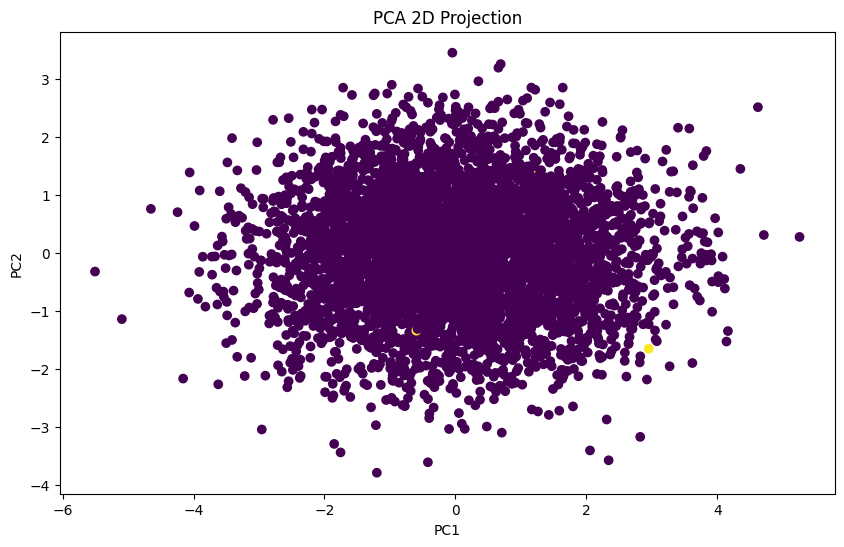

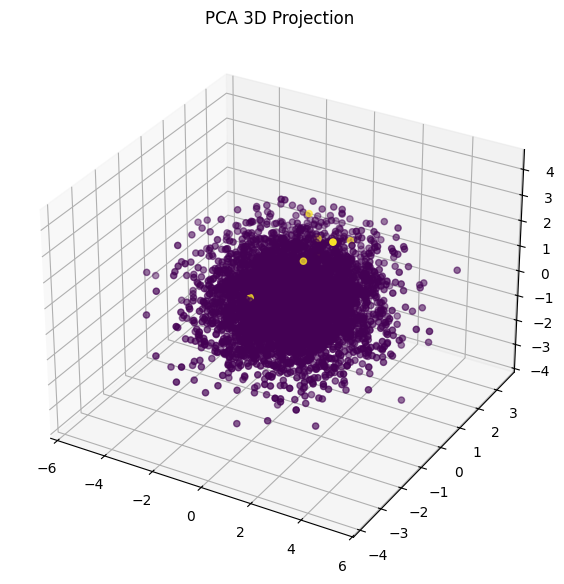

In [3]:
from mpl_toolkits.mplot3d import Axes3D

# PCA 2D

pca2 = PCA(
    n_components=2
)

X_pca2 = pca2.fit_transform(
    X_scaled
)

# PCA 3D

pca3 = PCA(
    n_components=3
)

X_pca3 = pca3.fit_transform(
    X_scaled
)

print(
    "2D Variance:",
    pca2.explained_variance_ratio_
)

print(
    "3D Variance:",
    pca3.explained_variance_ratio_
)

# 2D Plot

plt.figure(figsize=(10,6))

plt.scatter(

    X_pca2[:,0],

    X_pca2[:,1],

    c=df["defect_label"]

)

plt.title(
    "PCA 2D Projection"
)

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

# 3D Plot

fig = plt.figure(
    figsize=(10,7)
)

ax = fig.add_subplot(
    111,
    projection='3d'
)

ax.scatter(

    X_pca3[:,0],

    X_pca3[:,1],

    X_pca3[:,2],

    c=df["defect_label"]

)

ax.set_title(
    "PCA 3D Projection"
)

plt.show()

Feature Loading Matrix


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
temperature_c,0.000183,0.290199,0.221888,0.498987,-0.493015,0.568088,-0.227540,-0.000228
pressure_torr,0.029739,-0.182703,-0.416580,0.473909,0.548552,0.430240,0.285641,0.000374
gas_flow_sccm,-0.009163,0.221500,0.493830,-0.323940,0.601546,0.373426,-0.317401,-0.000187
etch_rate_nm_min,0.008233,-0.514767,0.583855,-0.054785,-0.136117,0.196373,0.577899,-0.001403
voltage_v,0.432373,0.575600,0.150733,0.120455,0.095557,-0.194558,0.453246,-0.438283
current_ma,0.556949,-0.441191,-0.103738,-0.102205,-0.080298,0.136407,-0.372428,-0.556950
power_consumption,0.708306,0.008713,0.012949,-0.006741,-0.004824,-0.012250,-0.011311,0.705487
process_step_encoded,-0.011296,-0.205708,0.398525,0.627282,0.245029,-0.507495,-0.296076,0.000677


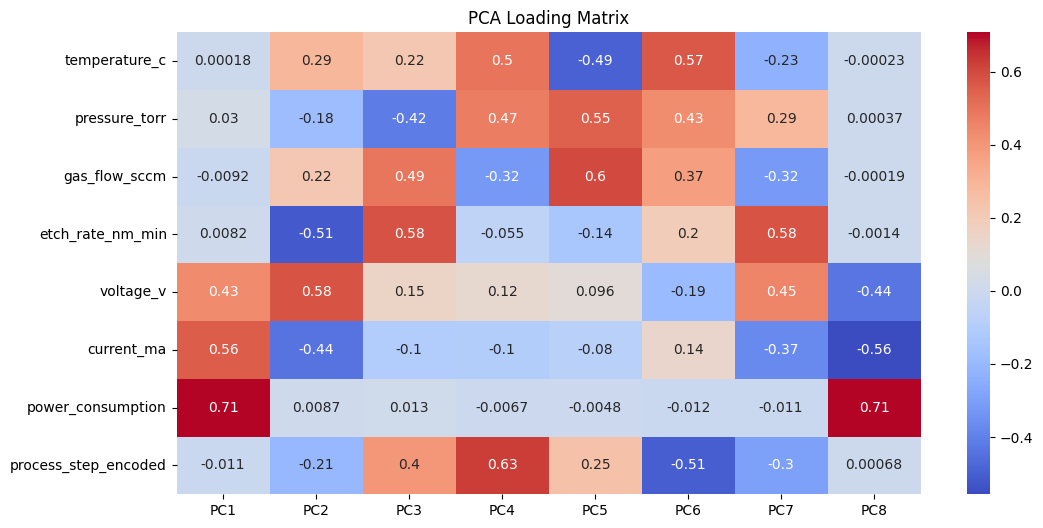

In [4]:
pca = PCA()

pca.fit(X_scaled)

loadings = pd.DataFrame(

    pca.components_.T,

    columns=[
        f"PC{i+1}"
        for i in range(
            len(features)
        )
    ],

    index=features

)

print(
    "Feature Loading Matrix"
)

display(loadings)

plt.figure(
    figsize=(12,6)
)

sns.heatmap(

    loadings,

    annot=True,

    cmap="coolwarm"

)

plt.title(
    "PCA Loading Matrix"
)

plt.show()

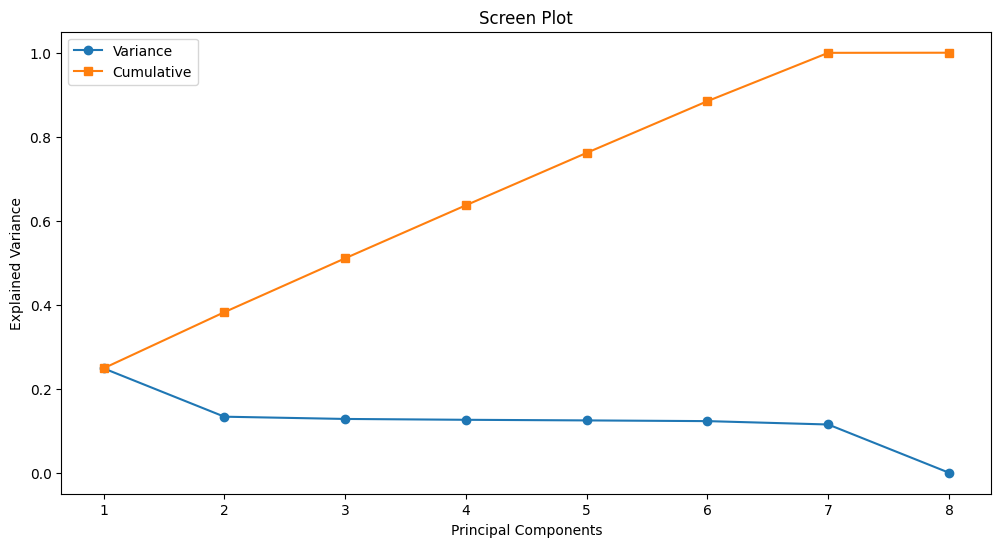

95% Variance Components: 7


In [5]:
pca = PCA()

pca.fit(X_scaled)

explained = (
    pca.explained_variance_ratio_
)

cumulative = np.cumsum(
    explained
)

plt.figure(
    figsize=(12,6)
)

plt.plot(

    range(
        1,
        len(explained)+1
    ),

    explained,

    marker="o",

    label="Variance"

)

plt.plot(

    range(
        1,
        len(explained)+1
    ),

    cumulative,

    marker="s",

    label="Cumulative"

)

plt.xlabel(
    "Principal Components"
)

plt.ylabel(
    "Explained Variance"
)

plt.title(
    "Screen Plot"
)

plt.legend()

plt.show()

print(
    "95% Variance Components:",
    np.argmax(
        cumulative >= 0.95
    ) + 1
)

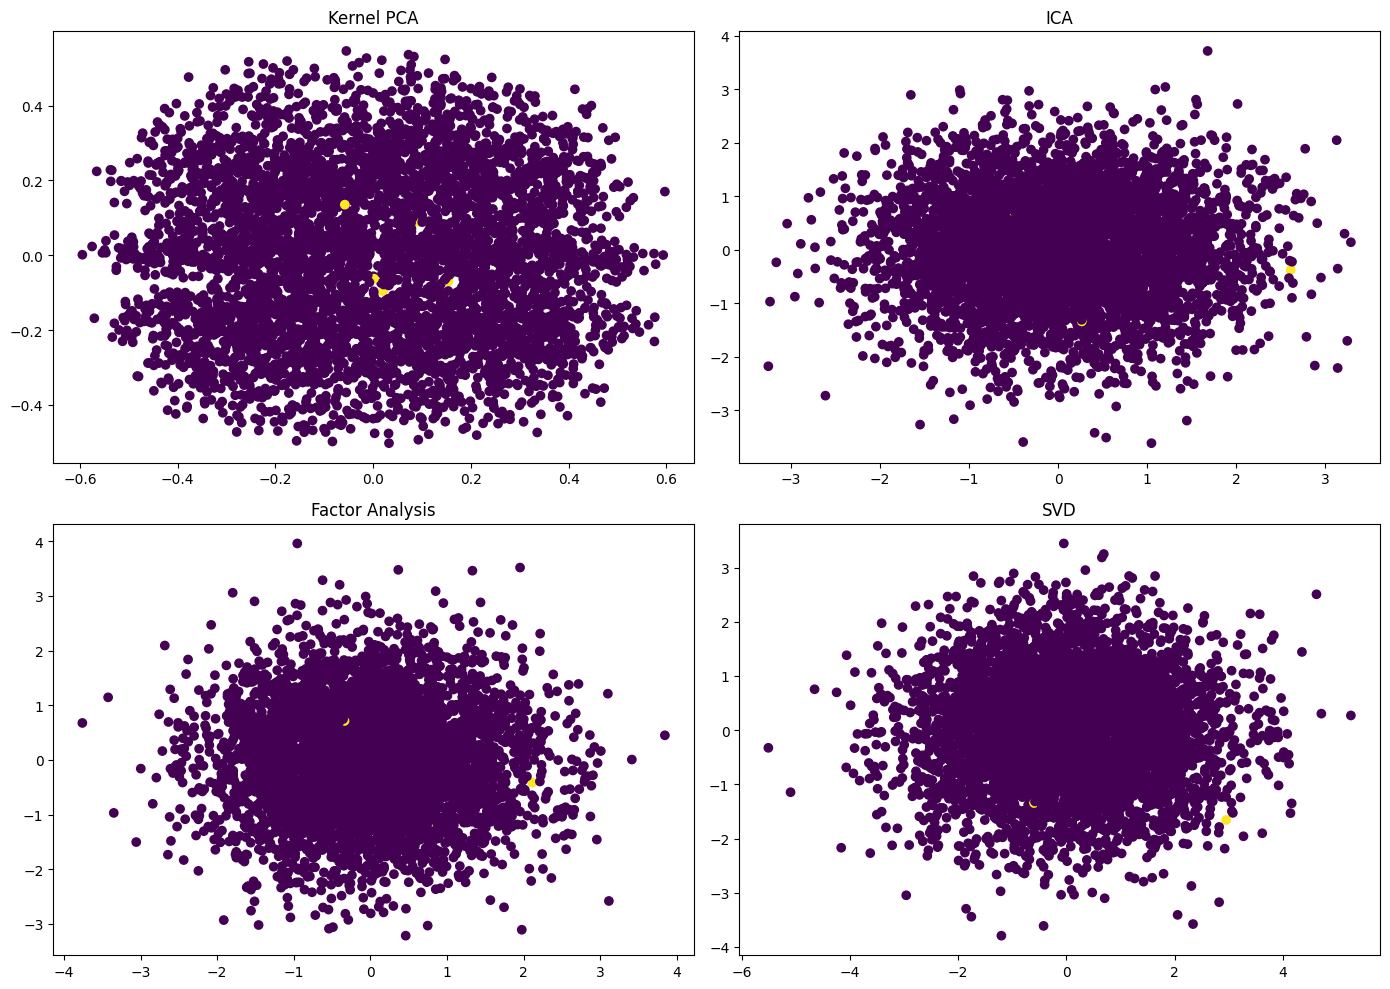

In [6]:
results = {}

# Kernel PCA

kpca = KernelPCA(
    n_components=2,
    kernel="rbf"
)

results["Kernel PCA"] = (
    kpca.fit_transform(
        X_scaled
    )
)

# ICA

ica = FastICA(
    n_components=2,
    random_state=42
)

results["ICA"] = (
    ica.fit_transform(
        X_scaled
    )
)

# Factor Analysis

fa = FactorAnalysis(
    n_components=2
)

results["Factor Analysis"] = (
    fa.fit_transform(
        X_scaled
    )
)

# Truncated SVD

svd = TruncatedSVD(
    n_components=2
)

results["SVD"] = (
    svd.fit_transform(
        X_scaled
    )
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14,10)
)

for ax, (name, values) in zip(
    axes.flatten(),
    results.items()
):

    ax.scatter(

        values[:,0],

        values[:,1],

        c=df["defect_label"]

    )

    ax.set_title(name)

plt.tight_layout()

plt.show()


In [9]:
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

X_reconstructed = pca.inverse_transform(X_pca)

reconstruction_error = np.mean(
    (X_scaled - X_reconstructed)**2,
    axis=1
)

df["reconstruction_error"] = reconstruction_error

print(df["reconstruction_error"].describe())

count    5000.000000
mean        0.489366
std         0.327921
min         0.003201
25%         0.243713
50%         0.421073
75%         0.659682
max         2.396097
Name: reconstruction_error, dtype: float64


In [10]:
pca = PCA()

pca.fit(X_scaled)

pc_df = pd.DataFrame({

    "Principal Component":
    [f"PC{i+1}" for i in range(len(features))],

    "Explained Variance":
    pca.explained_variance_ratio_,

    "Eigen Value":
    pca.explained_variance_

})

pc_df

,Principal Component,Explained Variance,Eigen Value
0,PC1,0.248763,1.990505
1,PC2,0.133620,1.069172
2,PC3,0.128251,1.026210
3,PC4,0.126236,1.010088
4,PC5,0.124768,0.998345
5,PC6,0.123073,0.984785
6,PC7,0.115043,0.920525
7,PC8,0.000246,0.001971


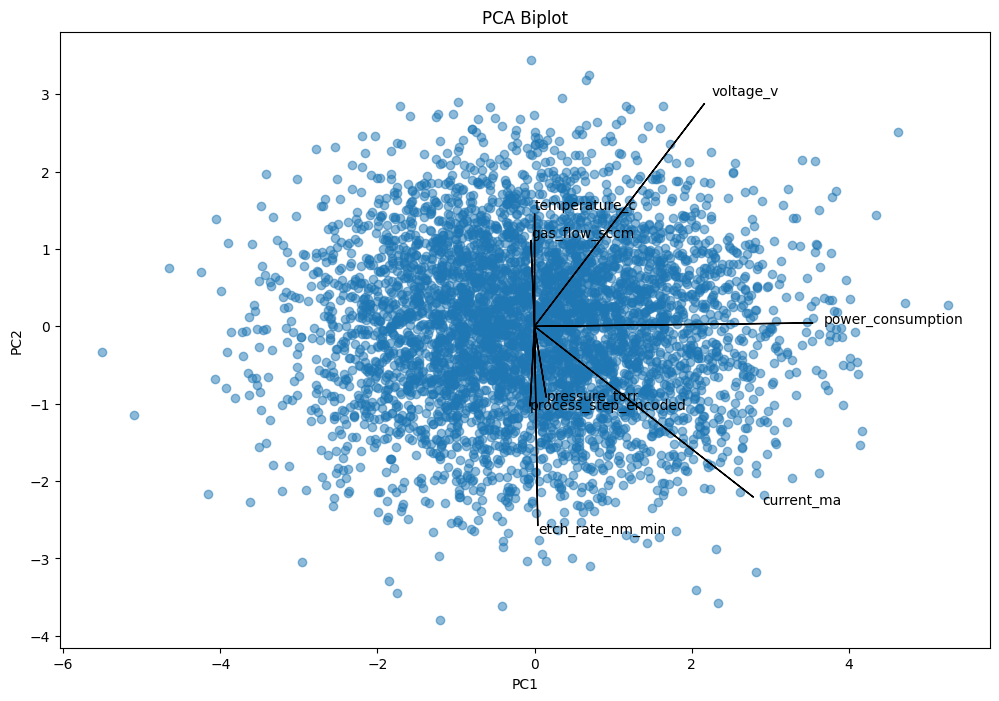

In [11]:
pca = PCA(n_components=2)

scores = pca.fit_transform(X_scaled)

loadings = pca.components_.T

plt.figure(figsize=(12,8))

plt.scatter(
    scores[:,0],
    scores[:,1],
    alpha=0.5
)

for i, feature in enumerate(features):

    plt.arrow(
        0,
        0,
        loadings[i,0]*5,
        loadings[i,1]*5
    )

    plt.text(
        loadings[i,0]*5.2,
        loadings[i,1]*5.2,
        feature
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Biplot")
plt.show()

In [12]:
contribution = pd.DataFrame(

    np.abs(loadings),

    columns=["PC1","PC2"],

    index=features

)

contribution["Total"] = (

    contribution["PC1"] +

    contribution["PC2"]

)

contribution.sort_values(
    "Total",
    ascending=False
)

,PC1,PC2,Total
voltage_v,0.432373,0.575600,1.007973
current_ma,0.556949,0.441191,0.998140
power_consumption,0.708306,0.008713,0.717019
etch_rate_nm_min,0.008233,0.514767,0.523000
temperature_c,0.000183,0.290199,0.290382
gas_flow_sccm,0.009163,0.221500,0.230663
process_step_encoded,0.011296,0.205708,0.217003
pressure_torr,0.029739,0.182703,0.212442


In [13]:
threshold = np.percentile(
    reconstruction_error,
    99
)

df["pca_anomaly"] = np.where(

    df["reconstruction_error"] >

    threshold,

    1,

    0

)

print(
    df["pca_anomaly"].value_counts()
)

pca_anomaly
0    4950
1      50
Name: count, dtype: int64


In [22]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

# Recreate the missing anomaly detection columns

# Z-Score Anomaly
z_scores = np.abs((X - X.mean()) / X.std())
df["zscore_anomaly"] = (z_scores > 3).any(axis=1).astype(int)

# Isolation Forest Anomaly
iso = IsolationForest(n_estimators=500, contamination=0.002, random_state=42)
iso.fit(X_scaled)
iso_pred = iso.predict(X_scaled)
df["isolation_forest"] = np.where(iso_pred == -1, 1, 0)

# One-Class SVM Anomaly
svm = OneClassSVM(kernel="rbf", gamma="scale", nu=0.002)
svm.fit(X_scaled)
svm_pred = svm.predict(X_scaled)
df["oneclass_svm"] = np.where(svm_pred == -1, 1, 0)

# LOF Anomaly
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.002, novelty=True)
lof.fit(X_scaled)
lof_pred = lof.predict(X_scaled)
df["lof_anomaly"] = np.where(lof_pred == -1, 1, 0)

comparison = pd.DataFrame({
    "Method": [
        "Z-Score",
        "Isolation Forest",
        "One-Class SVM",
        "LOF",
        "PCA Reconstruction"
    ],
    "Anomalies": [
        df["zscore_anomaly"].sum(),
        df["isolation_forest"].sum(),
        df["oneclass_svm"].sum(),
        df["lof_anomaly"].sum(),
        df["pca_anomaly"].sum()
    ]
})

comparison

,Method,Anomalies
0,Z-Score,89
1,Isolation Forest,10
2,One-Class SVM,79
3,LOF,10
4,PCA Reconstruction,50


In [24]:
df["iforest_score"] = -iso.decision_function(X_scaled)
df["svm_score"] = -svm.decision_function(X_scaled)
df["lof_score"] = -lof.decision_function(X_scaled)

z_scores = np.abs((X - X.mean()) / X.std())
df["zscore_score"] = z_scores.max(axis=1)

cov = np.cov(X_scaled, rowvar=False)
inv_cov = np.linalg.inv(cov)
mean_vec = np.mean(X_scaled, axis=0)
diff = X_scaled - mean_vec
df["mahalanobis_score"] = np.sqrt(np.sum(diff @ inv_cov * diff, axis=1))

df["iforest_anomaly"] = df["isolation_forest"]
df["svm_anomaly"] = df["oneclass_svm"]
df["mahalanobis_anomaly"] = np.where(
    df["mahalanobis_score"] > np.percentile(df["mahalanobis_score"], 99.5),
    1,
    0
)
df["zscore_anomaly"] = np.where(df["zscore_score"] > 3, 1, 0)

risk = (
    0.25 * df["iforest_score"]
    + 0.20 * df["svm_score"]
    + 0.15 * df["lof_score"]
    + 0.15 * df["mahalanobis_score"]
    + 0.10 * df["zscore_score"]
    + 0.15 * df["reconstruction_error"]
)

risk = (risk - risk.min()) / (risk.max() - risk.min())
df["risk_score"] = risk * 100

df["ensemble_votes"] = (
    df["iforest_anomaly"]
    + df["svm_anomaly"]
    + df["lof_anomaly"]
    + df["mahalanobis_anomaly"]
    + df["zscore_anomaly"]
)

df["ensemble_anomaly"] = (df["ensemble_votes"] >= 3).astype(int)

risk = (

    risk - risk.min()

) / (

    risk.max() - risk.min()

)

df["risk_score"] = (
    risk * 100
)

df["ensemble_votes"] = (

    df["iforest_anomaly"]

    +

    df["svm_anomaly"]

    +

    df["lof_anomaly"]

    +

    df["mahalanobis_anomaly"]

    +

    df["zscore_anomaly"]

)

df["ensemble_anomaly"] = (

    df["ensemble_votes"]

    >= 3

).astype(int)

In [25]:
comparison = pd.DataFrame({

    "Method":[

        "Z-Score",

        "Mahalanobis",

        "Isolation Forest",

        "One-Class SVM",

        "LOF",

        "Ensemble"

    ],

    "Anomalies":[

        df["zscore_anomaly"].sum(),

        df["mahalanobis_anomaly"].sum(),

        df["iforest_anomaly"].sum(),

        df["svm_anomaly"].sum(),

        df["lof_anomaly"].sum(),

        df["ensemble_anomaly"].sum()

    ]
})

comparison

,Method,Anomalies
0,Z-Score,89
1,Mahalanobis,25
2,Isolation Forest,10
3,One-Class SVM,79
4,LOF,10
5,Ensemble,12


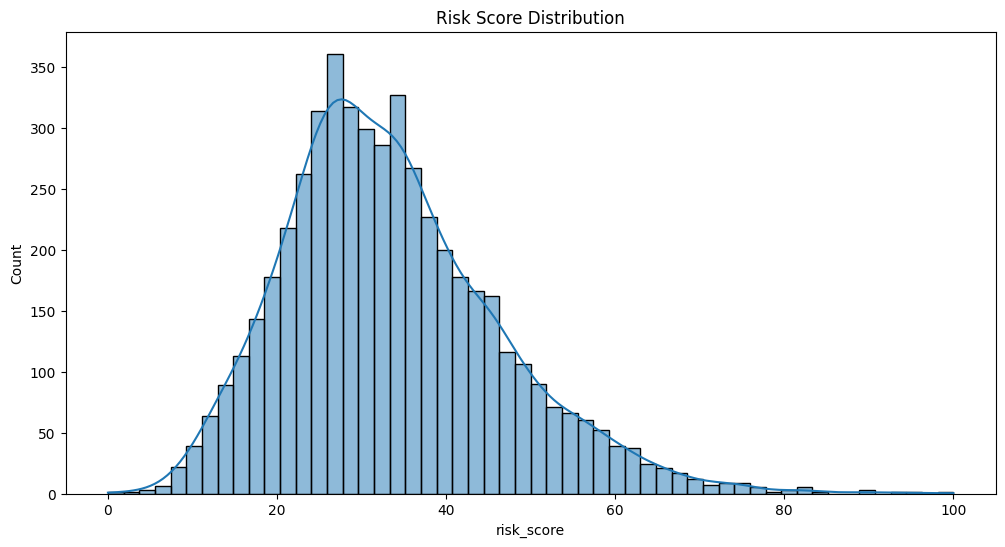

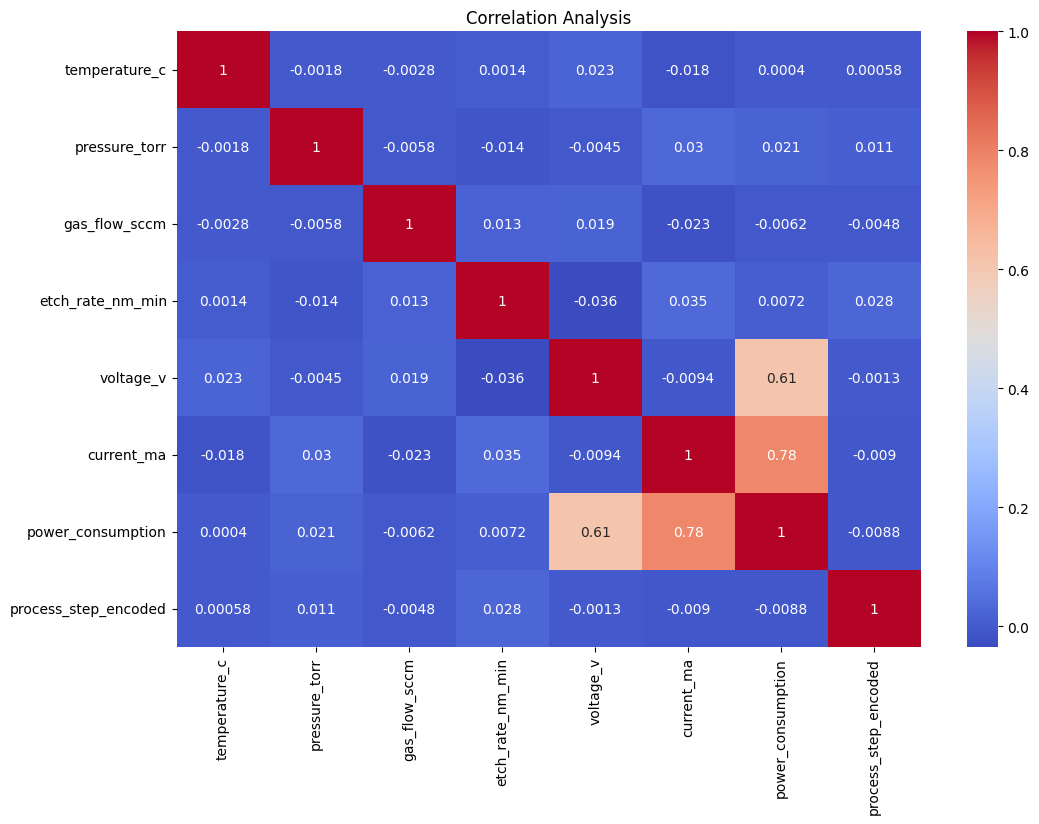

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.histplot(
    df["risk_score"],
    kde=True
)

plt.title(
    "Risk Score Distribution"
)

plt.show()

plt.figure(figsize=(12,8))

sns.heatmap(

    X.corr(),

    annot=True,

    cmap="coolwarm"

)

plt.title(
    "Correlation Analysis"
)

plt.show()